# Slinky dynamic simulation: settle under gravity, then pull

This notebook mirrors the setup in `slinky_2D_training_sim.ipynb`, but runs in two phases:

1. The slinky evolves dynamically under gravity until it is approximately settled.
2. The boundary motion is then applied through a `before_step(robot, t)` callback.

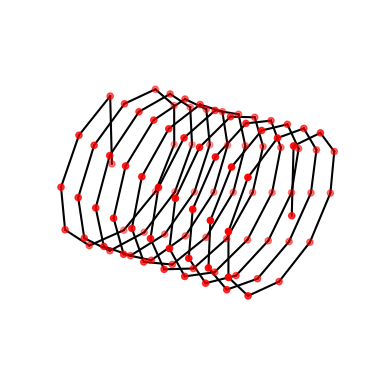

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dismech

geom = dismech.GeomParams(rod_r0=5e-3, shell_h=0)

material = dismech.Material(
    density=800,
    youngs_rod=1e7,
    youngs_shell=0,
    poisson_rod=0.5,
    poisson_shell=0,
)

dt = 1e-2
pull_duration = 1.5
settle_window = 0.2
max_settle_time = 3.0
speed_tol = 2e-3
required_settled_windows = 3

# trajectories:
traj = 15
output_dir = 'slinky_2D_data_new'
if traj== 1:
    # pulling
    save_data_in = output_dir + '/n3_traj1_pull_out_raw.npz'
    pull_final_displacement = np.array([1.5, 0.0, 0.0])
elif traj == 2:
    # diag up
    save_data_in = output_dir + '/n3_traj2_diag_up_raw.npz'
    pull_final_displacement = np.array([1.0, 0.0, 0.6])
elif traj == 3:
    # diag down
    save_data_in = output_dir + '/n3_traj3_diag_down_raw.npz'
    pull_final_displacement = np.array([1.0, 0.0, -0.6])

elif traj == 4:
    # diag2 up
    save_data_in = output_dir + '/n3_traj4_diag2_up_raw.npz'
    pull_final_displacement = np.array([0.5, 0.0, 1.5])
elif traj == 5:
    # diag2 down
    save_data_in = output_dir + '/n3_traj5_diag2_down_raw.npz'
    pull_final_displacement = np.array([0.5, 0.0, -1.5])

elif traj == 6:
    # vertical up
    save_data_in = output_dir + '/n3_traj6_vertical_up_raw.npz'
    pull_final_displacement = np.array([0.0, 0.0, 0.6])
elif traj == 7:
    # vertical down
    save_data_in = output_dir + '/n3_traj7_vertical_down_raw.npz'
    pull_final_displacement = np.array([0.0, 0.0, -0.5])
elif traj == 8:
    # diagonal
    save_data_in = output_dir + '/n3_traj8_diagonal_up_raw.npz'
    pull_final_displacement = np.array([1.0, 0.0, 1.0])    
elif traj == 9:
    # diagonal
    save_data_in = output_dir + '/n3_traj9_diagonal_down_raw.npz'
    pull_final_displacement = np.array([1.0, 0.0, -1.0])    
elif traj == 10:
    # diagonal3 up
    save_data_in = output_dir + '/n3_traj10_diagonal3_up_raw.npz'
    pull_final_displacement = np.array([1.0, 0.0, 0.2])
elif traj == 11:
    # diagonal3 down
    save_data_in = output_dir + '/n3_traj11_diagonal3_down_raw.npz'
    pull_final_displacement = np.array([1.0, 0.0, -0.2])
elif traj == 12:
    # diagonal4 up
    save_data_in = output_dir + '/n3_traj12_diagonal4_up_raw.npz'
    pull_final_displacement = np.array([0.5, 0.0, 0.75])
elif traj == 13:
    # diagonal4 down
    save_data_in = output_dir + '/n3_traj13_diagonal4_down_raw.npz'
    pull_final_displacement = np.array([0.5, 0.0, -0.75])
elif traj == 14:
    # diagonal5 up
    save_data_in = output_dir + '/n3_traj14_diagonal5_up_raw.npz'
    pull_final_displacement = np.array([0.2, 0.0, 1.25])
elif traj == 15:
    # diagonal5 down
    save_data_in = output_dir + '/n3_traj15_diagonal5_down_raw.npz'
    pull_final_displacement = np.array([0.2, 0.0, -0.5])

sim_template = dict(
    static_sim=False,
    two_d_sim=False,
    use_mid_edge=False,
    use_line_search=True,
    line_search_iters=2,
    show_floor=False,
    log_data=True,
    log_step=1,
    dt=dt,
    max_iter=50,
    plot_step=1,
    tol=1e-4,
    ftol=1e-4,
    dtol=1e-2,
)

env = dismech.Environment()
env.add_force('damping', eta=10)
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))

# geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')
geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky_top_bottom.txt')


In [2]:
def make_robot(total_time):
    sim_params = dismech.SimParams(total_time=total_time, **sim_template)
    robot = dismech.SoftRobot(geom, material, geo, sim_params, env)
    return robot

def enforce_fixed_points(robot, fixed_points):
    return robot.fix_nodes(fixed_points)

def with_total_time(robot, total_time):
    new_params = dismech.SimParams(total_time=total_time, **sim_template)
    new_robot = robot.update()
    new_robot._SoftRobot__sim_params = new_params
    return new_robot


def run_segment(robot, total_time, before_step=None):
    robot = with_total_time(robot, total_time)
    stepper = dismech.ImplicitEulerTimeStepper(robot)
    stepper.before_step = before_step
    return stepper.simulate()


def max_nodal_speed(robot):
    velocities = robot.state.u[:robot.end_node_dof_index].reshape(-1, 3)
    return np.linalg.norm(velocities, axis=1).max()


def append_segment(all_robots, all_times, all_forces, robots, t_arr, Fs, time_offset):
    if not all_robots:
        all_robots.extend(robots)
        all_times.extend(t_arr)
        all_forces.extend(Fs)
    else:
        all_robots.extend(robots[1:])
        all_times.extend([time_offset + t for t in t_arr[1:]])
        all_forces.extend(Fs[1:])


def run_until_settled(robot, window_time, max_total_time, speed_tol, settled_windows):
    all_robots = []
    all_times = []
    all_forces = []
    settle_speeds = []
    stable_count = 0
    elapsed = 0.0

    current_robot = robot
    while elapsed < max_total_time:
        robots, t_arr, _, Fs = run_segment(current_robot, window_time)
        append_segment(all_robots, all_times, all_forces, robots, t_arr, Fs, elapsed)

        current_robot = robots[-1]
        elapsed = all_times[-1]
        speed = max_nodal_speed(current_robot)
        settle_speeds.append(speed)
        print(f'settle time = {elapsed:.3f} s, max nodal speed = {speed:.6e} m/s')

        if speed < speed_tol:
            stable_count += 1
        else:
            stable_count = 0

        if stable_count >= settled_windows:
            break

    settled = stable_count >= settled_windows
    return current_robot, np.array(all_robots, dtype=object), np.array(all_times), np.array(all_forces), np.array(settle_speeds), settled


In [3]:
robot0 = make_robot(total_time=settle_window)

fixed_points = np.array([0, 1, robot0.n_nodes - 2, robot0.n_nodes - 1])

robot0 = enforce_fixed_points(robot0, fixed_points)

end_node_idxs = np.array([robot0.n_nodes - 2, robot0.n_nodes - 1])

settled_robot, settle_robots, settle_t_arr, settle_Fs, settle_speeds, settled = run_until_settled(
    robot0,
    window_time=settle_window,
    max_total_time=max_settle_time,
    speed_tol=speed_tol,
    settled_windows=required_settled_windows,
)

print('Settled:', settled)
print('Equilibrium time used:', settle_t_arr[-1], 's')
print('Final max nodal speed:', settle_speeds[-1])


iter: 1, error: 0.115
iter: 2, error: 0.058
current_time:  0.01
iter: 1, error: 0.176
iter: 2, error: 0.147
current_time:  0.02
iter: 1, error: 0.216
iter: 2, error: 0.258
iter: 3, error: 0.000
current_time:  0.03
iter: 1, error: 0.239
iter: 2, error: 0.406
iter: 3, error: 0.000
current_time:  0.04
iter: 1, error: 0.252
iter: 2, error: 0.560
iter: 3, error: 0.000
current_time:  0.05
iter: 1, error: 0.259
iter: 2, error: 0.688
iter: 3, error: 0.000
current_time:  0.060000000000000005
iter: 1, error: 0.260
iter: 2, error: 0.776
iter: 3, error: 0.000
current_time:  0.07
iter: 1, error: 0.259
iter: 2, error: 0.823
iter: 3, error: 0.000
current_time:  0.08
iter: 1, error: 0.256
iter: 2, error: 0.835
iter: 3, error: 0.000
current_time:  0.09
iter: 1, error: 0.251
iter: 2, error: 0.819
iter: 3, error: 0.000
current_time:  0.09999999999999999
iter: 1, error: 0.245
iter: 2, error: 0.784
iter: 3, error: 0.000
current_time:  0.10999999999999999
iter: 1, error: 0.238
iter: 2, error: 0.736
iter: 3,

In [4]:
pull_robot = settled_robot.fix_nodes(end_node_idxs)
pull_displacements = []

def pull_after_settle(robot, t):
    previous_fraction = min(t / pull_duration, 1.0)
    next_fraction = min((t + robot.sim_params.dt) / pull_duration, 1.0)
    perturbation = (next_fraction - previous_fraction) * pull_final_displacement
    robot = robot.move_nodes(end_node_idxs, perturbation)
    pull_displacements.append((t, robot.state.q[robot.end_node_dof_index - 3]))
    return robot

pull_robots, pull_t_local, pull_f_norms, pull_Fs = run_segment(
    pull_robot,
    total_time=pull_duration,
    before_step=pull_after_settle,
)


iter: 1, error: 28.837
iter: 2, error: 68.630
iter: 3, error: 7.682
iter: 4, error: 4.645
iter: 5, error: 2.576
iter: 6, error: 1.460
iter: 7, error: 0.832
iter: 8, error: 0.466
iter: 9, error: 0.255
iter: 10, error: 0.136
iter: 11, error: 0.071
iter: 12, error: 0.037
iter: 13, error: 0.019
iter: 14, error: 0.010
iter: 15, error: 0.005
current_time:  0.01
iter: 1, error: 28.081
iter: 2, error: 71.720
iter: 3, error: 8.282
iter: 4, error: 5.117
iter: 5, error: 2.811
iter: 6, error: 1.587
iter: 7, error: 0.906
iter: 8, error: 0.510
iter: 9, error: 0.280
iter: 10, error: 0.150
iter: 11, error: 0.079
iter: 12, error: 0.041
iter: 13, error: 0.021
iter: 14, error: 0.011
iter: 15, error: 0.006
current_time:  0.02
iter: 1, error: 28.245
iter: 2, error: 71.893
iter: 3, error: 8.195
iter: 4, error: 5.255
iter: 5, error: 2.898
iter: 6, error: 1.642
iter: 7, error: 0.939
iter: 8, error: 0.529
iter: 9, error: 0.290
iter: 10, error: 0.155
iter: 11, error: 0.081
iter: 12, error: 0.042
iter: 13, error

In [5]:
pull_t_arr = settle_t_arr[-1] + np.array(pull_t_local)

robots = list(settle_robots) + list(pull_robots[1:])
t_arr = np.concatenate([settle_t_arr, pull_t_arr[1:]])
Fs_arr = np.concatenate([settle_Fs, np.array(pull_Fs)[1:]], axis=0)

qs = np.stack([rb.state.q for rb in robots])
vs = np.stack([rb.state.u for rb in robots])

print('Combined trajectory shape:', qs.shape)
print('Combined force history shape:', Fs_arr.shape)


Combined trajectory shape: (371, 407)
Combined force history shape: (371, 407)


In [6]:
options = dismech.AnimationOptions(title='Slinky settle then pull', plot_step=10)
fig = dismech.get_interactive_animation_plotly(robots[-1], t_arr, qs, options)
fig.show()


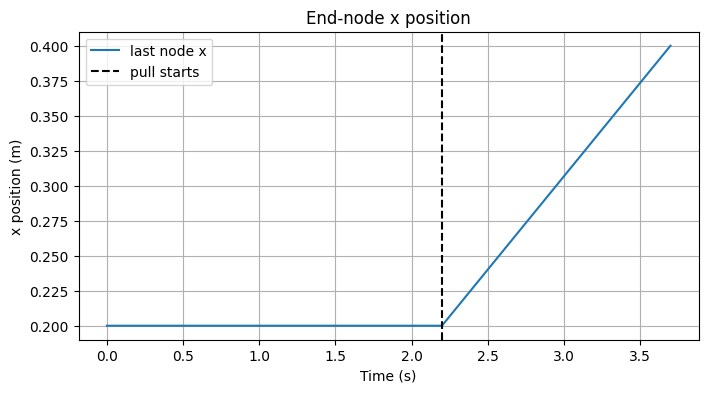

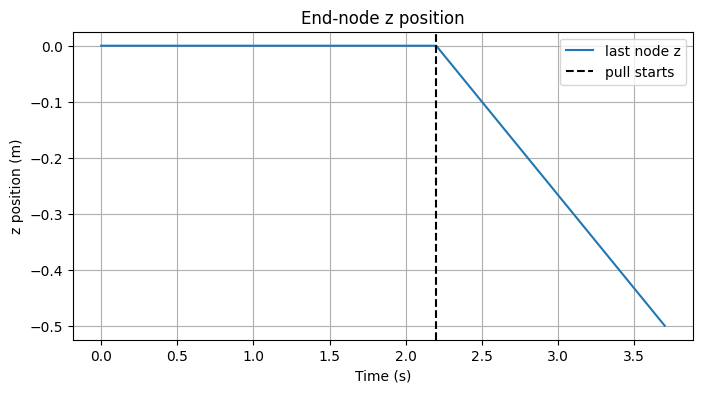

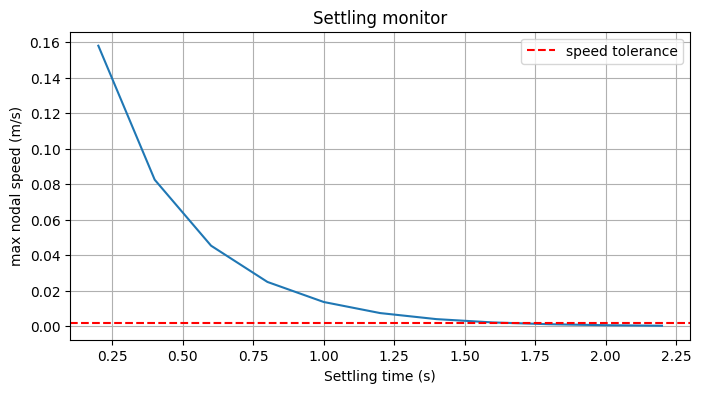

In [7]:
last_node_x = qs[:, robots[-1].end_node_dof_index - 3]
last_node_z = qs[:, robots[-1].end_node_dof_index - 1]

plt.figure(figsize=(8, 4))
plt.plot(t_arr, last_node_x, label='last node x')
plt.axvline(settle_t_arr[-1], color='k', linestyle='--', label='pull starts')
plt.xlabel('Time (s)')
plt.ylabel('x position (m)')
plt.title('End-node x position')
plt.grid(True)
plt.legend()

plt.figure(figsize=(8, 4))
plt.plot(t_arr, last_node_z, label='last node z')
plt.axvline(settle_t_arr[-1], color='k', linestyle='--', label='pull starts')
plt.xlabel('Time (s)')
plt.ylabel('z position (m)')
plt.title('End-node z position')
plt.grid(True)
plt.legend()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(settle_speeds) + 1) * settle_window, settle_speeds)
plt.axhline(speed_tol, color='r', linestyle='--', label='speed tolerance')
plt.xlabel('Settling time (s)')
plt.ylabel('max nodal speed (m/s)')
plt.title('Settling monitor')
plt.grid(True)
plt.legend()


In [8]:
# # Optional: save the animation if desired.
# ani = dismech.get_animation(robots[-1], t_arr, qs, options)
# ani.save('slinky_settle_then_pull.gif')


In [9]:
# Training data starts from the settled configuration and includes only the pull trajectory.
qs = np.stack([rb.state.q for rb in pull_robots])
Fs_arr = np.array(pull_Fs)
t_arr = np.array(pull_t_local)

# save the data so that we don't have to run simulation again
np.savez(save_data_in, qs=qs, F=Fs_arr, t=t_arr)

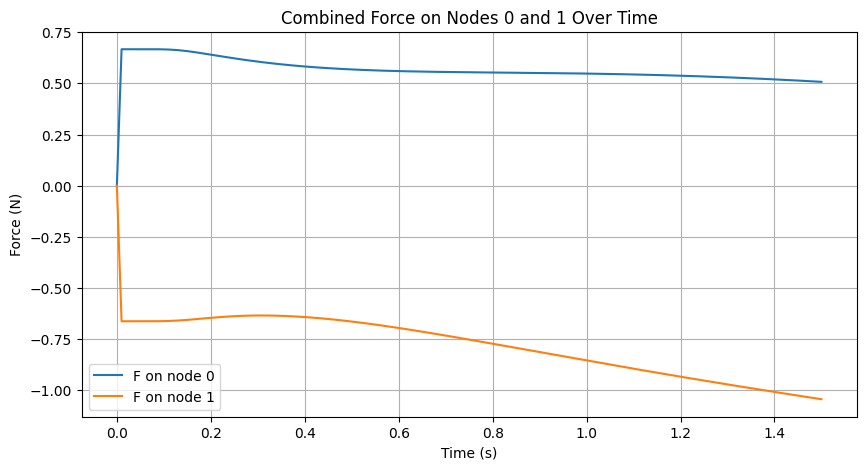

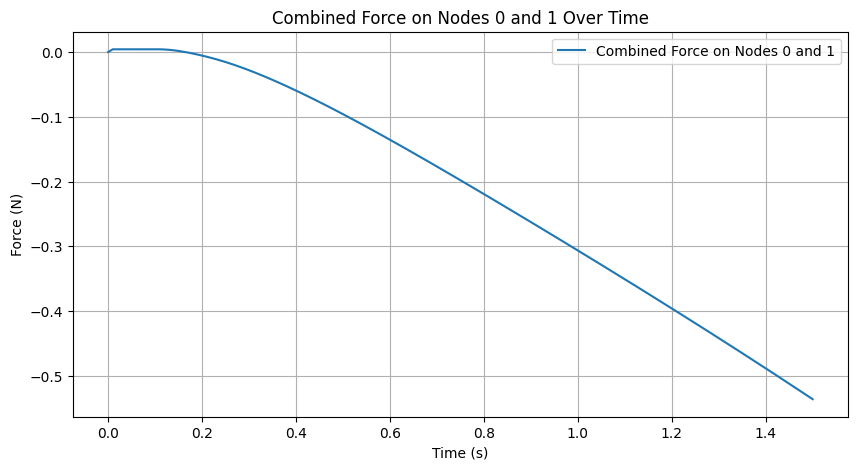

In [10]:
# plot the combined force on the 0th and the 1st node
plt.figure(figsize=(10, 5))
plt.plot(t_arr, Fs_arr[:, 0], label='F on node 0')
plt.plot(t_arr, Fs_arr[:, 3], label='F on node 1')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.title('Combined Force on Nodes 0 and 1 Over Time')
plt.legend()
plt.grid()
plt.show()

# now add them together and plot
plt.figure(figsize=(10, 5))
plt.plot(t_arr, Fs_arr[:, 0] + Fs_arr[:, 3], label='Combined Force on Nodes 0 and 1')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.title('Combined Force on Nodes 0 and 1 Over Time')
plt.legend()
plt.grid()
plt.show()